## 1. Import Necessary Libraries

In [2]:
import tensorflow as tf
import keras 
from matplotlib import pyplot as plt
import numpy as np

## 2. Import Data

In [3]:
(X_train, _),(X_test, _)= keras.datasets.mnist.load_data(path="mnist.npz")

In [4]:
X_train.shape,X_test.shape

((60000, 28, 28), (10000, 28, 28))

## 3. Data Preparation

### 3.1 Add the Channel

In [5]:
X_train=X_train.reshape(60000, 28, 28,1)
X_test=X_test.reshape(10000, 28, 28,1)

In [6]:
X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

### 3.2 Normalize 

In [7]:
X_train=X_train/255.0
X_test=X_test/255.0

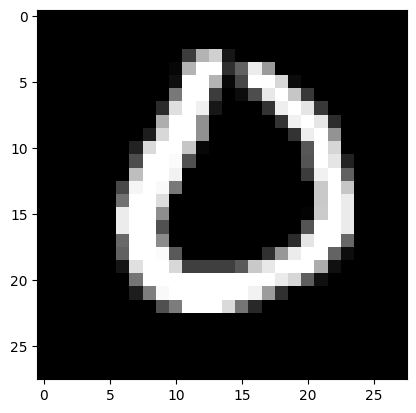

In [8]:
plt.imshow(X_train[2500],cmap="grey")

### 3.3 Add Noise

In [9]:
X_train_noise=X_train+0.25*np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noise=X_test+0.25*np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

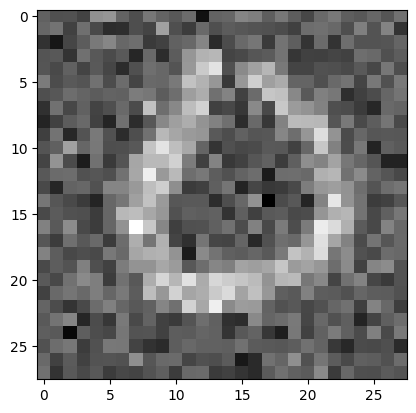

In [10]:
plt.imshow(X_train_noise[2500],cmap="grey")

In [11]:
X_train_noise.max(),X_train_noise.min()

(np.float64(2.205993475325389), np.float64(-1.3255743444455421))

### 3.4 Add the Clip

In [12]:
X_train_clipped=np.clip(a=X_train_noise,a_min=0.,a_max=1,) #I will have the positive numbers
X_test_clipped=np.clip(a=X_test_noise,a_min=0.,a_max=1,)

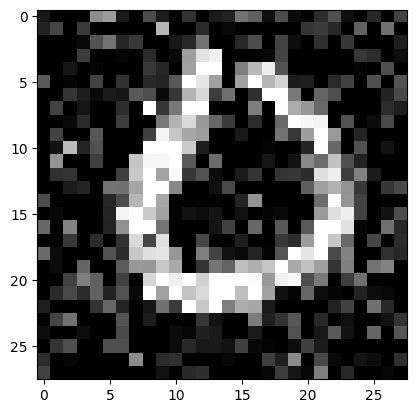

In [13]:
plt.imshow(X_train_clipped[2500],cmap="grey")

## 4. Model Building

### What is auto encoder?
An autoencoder is just 2 Neural Networks glued together

* The first half (encoder) compresses . (compress)
* The second half (decoder) reconstructs. (expand)
  
 where the compressed summary lives.

In [14]:
from keras import Sequential
from keras.layers import Conv2D,MaxPool2D,UpSampling2D

In [15]:
model=Sequential()
#Encoder =Compress the info
model.add(Conv2D( filters=32 ,kernel_size=(3, 3),strides=(1, 1),padding='same',activation="relu",input_shape=(28,28,1)))
model.add(MaxPool2D( pool_size=(2, 2)))
model.add(Conv2D( filters=8 ,kernel_size=(3, 3),strides=(1, 1),padding='same',activation="relu"))
model.add(MaxPool2D( pool_size=(2, 2)))

#Decoder = Expands
model.add(Conv2D( filters=8 ,kernel_size=(3, 3),strides=(1, 1),padding='same',activation="relu"))
model.add(UpSampling2D( size=(2, 2)))
model.add(Conv2D( filters=32 ,kernel_size=(3, 3),strides=(1, 1),padding='same',activation="relu"))
model.add(UpSampling2D( size=(2, 2)))
model.add(Conv2D( filters=1 ,kernel_size=(3, 3),strides=(1, 1),padding='same',activation="relu"))

model.summary()

C:\Users\Abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 8)           │           2,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │           2,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,841 (22.82 KB)

 Trainable params: 5,841 (22.82 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Compilation

In [16]:
model.compile(optimizer='adam', loss="mean_squared_error", metrics=["accuracy"],)

## 6. Model Training

In [17]:
model.fit( x=X_train_clipped,y=X_train,batch_size=32,epochs=5, validation_data=(X_test,X_test_clipped))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8139 - loss: 0.0112 - val_accuracy: 0.4644 - val_loss: 0.0377
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8147 - loss: 0.0070 - val_accuracy: 0.4650 - val_loss: 0.0363
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8149 - loss: 0.0064 - val_accuracy: 0.4651 - val_loss: 0.0359
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8150 - loss: 0.0060 - val_accuracy: 0.4653 - val_loss: 0.0359
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8150 - loss: 0.0058 - val_accuracy: 0.4654 - val_loss: 0.0354


## 7. Model Evaluation

In [18]:
model.evaluate(X_test_clipped,X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8141 - loss: 0.0057


[0.00568853784352541, 0.8141332268714905]

## 8. Model Prediction

In [19]:
y_pred=model.predict(X_test_clipped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


### Original_Image

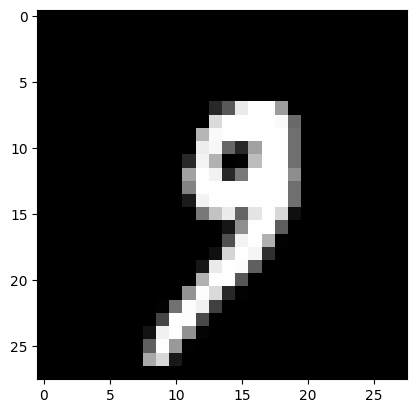

In [20]:
plt.imshow(X_test[1000],cmap="grey")

### Noisey_Image

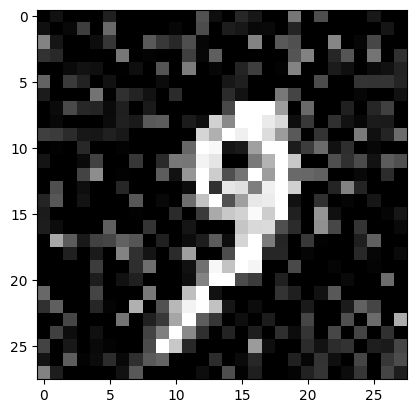

In [21]:
plt.imshow(X_test_clipped[1000],cmap="grey")

### Predicted_Image

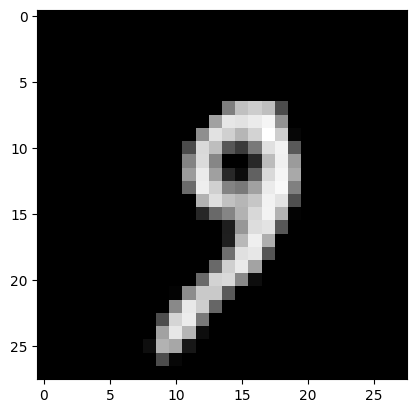

In [22]:
plt.imshow(y_pred[1000],cmap="grey")

## 9. Save the model

In [23]:
model.save("denoising.h5")

# THE END